
<div style="background-color: #FF0000; padding: 40px; border-radius: 12px; text-align: center; color: white; font-family: 'Outfit', sans-serif; box-shadow: 0 15px 35px rgba(255,0,0,0.3); margin-bottom: 25px;">
    <h1 style="font-size: 3.5em; margin: 0; font-weight: 900; letter-spacing: -2px; text-transform: uppercase;">Strategic Insights</h1>
    <p style="font-size: 1.6em; margin: 15px 0; font-weight: 300;">YouTube's Absolute Titans: A Deep-Dive into the Top 1000 Channels</p>
    <div style="margin-top: 25px; border-top: 1px solid rgba(255,255,255,0.3); padding-top: 20px; display: flex; justify-content: center; gap: 40px;">
        <div><span style="opacity: 0.7;">Author:</span> <b>Sitt Min Thar</b></div>
        <div><span style="opacity: 0.7;">Report Date:</span> <b>2026-04-14</b></div>
        <div><span style="opacity: 0.7;">Status:</span> <b>Final Release</b></div>
    </div>
</div>



# Navigational Roadmap
Explore the analysis by jumping to specific sections:

1. [Section 0: Global Configuration](#section0) — Environment & Themes
2. [Section 1: Data Acquisition](#section1) — Loading & Health Check
3. [Section 2: Feature Matrix Engineering](#section2) — Transforming Raw Data
4. [Section 3: Executive KPI Dashboard](#section3) — High-Level Snapshot
5. [Section 4: Reach & Reach Concentration](#section4) — Gini & Lorenz
6. [Section 5: Geographic Market Concentration](#section5) — Global Hotspots
7. [Section 6: Taxonomy & Content Synergy](#section6) — Topic Analysis
8. [Section 7: Temporal Growth Signatures](#section7) — Channel Longevity
9. [Section 8: Content Efficiency Quadrants](#section8) — Views/Sub Ratios
10. [Section 9: Linguistic Core & WordClouds](#section9) — NLP Analysis
11. [Section 10: The Elite Spotlights](#section10) — Channel Profiles
12. [Section 11: Quantitative Deep Dive](#section11) — Stats & Corrs
13. [Section 12: Predictive Channel Archetypes](#section12) — ML Insights
14. [Section 13: Tactical Business Strategy](#section13) — Success Formulas
15. [Section 14: Synthesis & Final Verdict](#section14) — Key Takeaways


<a id='section0'></a>
##  Section 0 — Global Configuration

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
import warnings
from datetime import datetime
from collections import Counter
warnings.filterwarnings('ignore')

# Premium Design System
YT_RED, YT_DARK, YT_GREY = "#FF0000", "#0F0F0F", "#282828"
pio.templates.default = "plotly_dark"
plt.style.use('dark_background')
plt.rcParams.update({
    'figure.dpi': 200, 
    'figure.facecolor': YT_DARK, 
    'axes.facecolor': YT_DARK,
    'axes.grid': True, 
    'grid.alpha': 0.1,
    'font.family': 'sans-serif',
    'axes.titleweight': 'bold'
})

def watermark(obj):
    if hasattr(obj, 'transAxes'): # It's an Axes
        obj.text(0.99, 0.01, 'Analysis: Sitt Min Thar', transform=obj.transAxes, color='grey', alpha=0.4, ha='right', fontsize=8)
    else: # It's a Figure
        obj.text(0.99, 0.01, 'Analysis: Sitt Min Thar', color='grey', alpha=0.4, ha='right', fontsize=8)

def format_number(n):
    if n >= 1e9: return f"{n/1e9:.2f}B"
    if n >= 1e6: return f"{n/1e6:.1f}M"
    return str(int(n))

import plotly
print(f"Environment Verified")
print(f"Pandas: {pd.__version__} | Plotly: {plotly.__version__}")


Environment Verified
Pandas: 3.0.1 | Plotly: 6.6.0


<a id='section1'></a>
## Section 1 — Data Acquisition & Health Check

,Column,Dtype,Missing %,Unique,Sample
0,rank,int64,0.00%,1000,1
1,title,str,0.00%,995,MrBeast
2,custom_url,str,0.50%,990,@mrbeast
3,published_at,str,0.00%,995,2012-02-20T00:43:50Z
4,country,str,14.60%,53,US
5,default_language,str,86.20%,22,en
6,description,str,5.60%,937,"SUBSCRIBE FOR A COOKIE! New MrBeast or MrBeast Gaming video every single Saturday at noon eastern time! Accomplishments: - Raised $20,000,000 To Plant 20,000,000 Trees - Removed 30,000,000 pounds of trash from the ocean - Helped 2,000 people walk again - Helped 1,000 blind people see - Helped 1,000 deaf people hear - Built wells in Africa - Built and gave away 100 houses - Adopted every dog in a shelter (twice) - Given millions to charity - Started my own snack company Feastables - Started my own software company Viewstats - Started Lunchly, a tasty, better-for-you lunch option - Gave away a private island (twice) - Gave away 1 million meals - I counted to 100k - Ran a marathon in the world's largest shoes - Survived 50 hours in Antarctica - Recreated Squid Game in real life - Created the largest competition show with 1000 people (Beast Games) - Gave $5,000,000 to one person - Passed T-Series to become most subscribed YouTube channel 🥹 you get it, I appreciate all of you so much :)"
7,views,float64,0.00%,985,117242000000.0
8,subscribers,int64,0.00%,369,476000000
9,videos,int64,0.00%,911,963


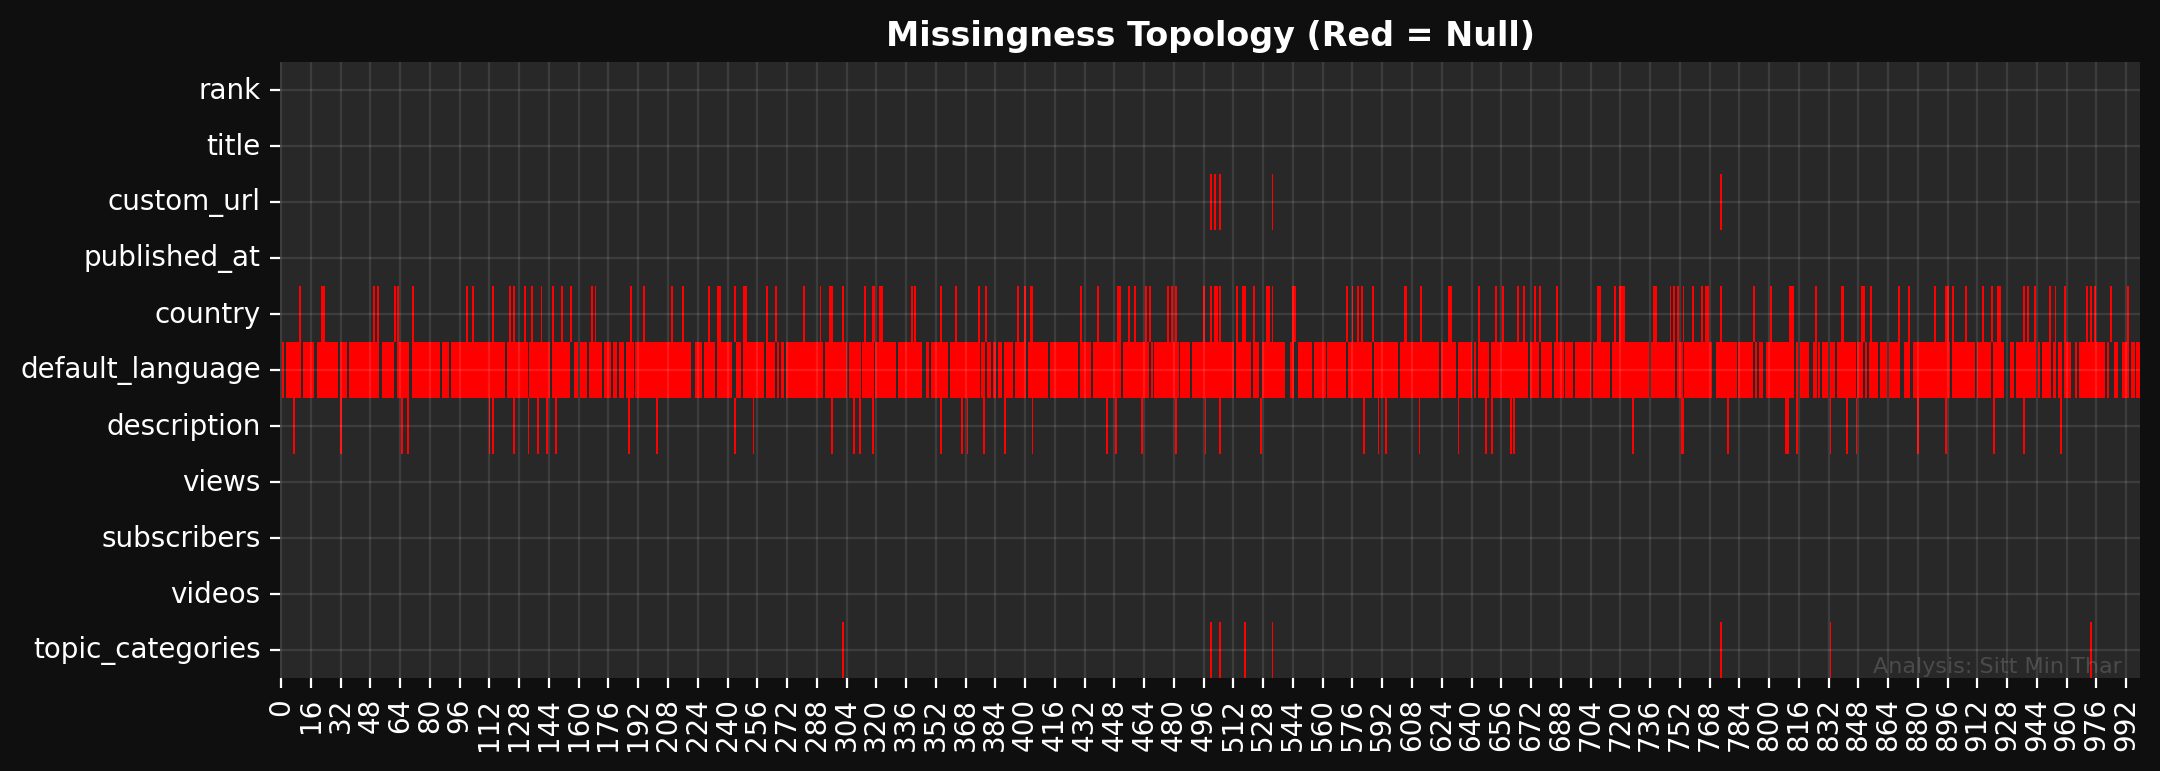

In [16]:
# --- 1.1 Load and Inspect ---
df = pd.read_csv('youtube_top_1000_by_subscribers.csv')

# --- 1.2 Data Quality Report ---
quality_report = []
for col in df.columns:
    quality_report.append({
        'Column': col,
        'Dtype': str(df[col].dtype),
        'Missing %': f"{(df[col].isna().sum()/len(df))*100:.2f}%",
        'Unique': df[col].nunique(),
        'Sample': str(df[col].dropna().iloc[0]) if not df[col].dropna().empty else "N/A"
    })

report_df = pd.DataFrame(quality_report)
display(report_df.style.set_properties(**{'text-align': 'left'}).set_table_styles([{'selector': 'th', 'props': [('background-color', YT_GREY), ('color', 'white')]}]))

# --- 1.3 Missing Values Heatmap ---
plt.figure(figsize=(12, 4))
sns.heatmap(df.iloc[:, :15].isna().T, cmap=['#282828', '#FF0000'], cbar=False)
plt.title('Missingness Topology (Red = Null)')
watermark(plt.gca())
plt.show()


<a id='section2'></a>
## Section 2 — Feature Matrix Engineering

In [17]:
df['published_at'] = pd.to_datetime(df['published_at'], format='ISO8601')
df['channel_age_years'] = (datetime(2024, 1, 1) - df['published_at'].dt.tz_localize(None)).dt.days / 365.25

# Performance Efficiency Metrics
df['views_per_subscriber'] = df['views'] / df['subscribers']
df['views_per_video'] = np.where(df['videos'] > 0, df['views'] / df['videos'], np.nan)
df['subscribers_per_video'] = np.where(df['videos'] > 0, df['subscribers'] / df['videos'], np.nan)

# Taxonomical Extraction
def parse_topics(t):
    if pd.isna(t): return []
    return [x.split('/')[-1].replace('_',' ') for x in str(t).split('|')]

df['topics_list'] = df['topic_categories'].apply(parse_topics)
df['primary_topic'] = df['topics_list'].apply(lambda x: x[0] if len(x) > 0 else "Unknown")
df['topic_count'] = df['topics_list'].apply(len)

# Temporal Eras
df['creation_year'] = df['published_at'].dt.year
def get_era(year):
    if year < 2010: return "Pioneer"
    if year <= 2015: return "Growth"
    if year <= 2019: return "Boom"
    return "Modern"
df['creation_era'] = df['creation_year'].apply(get_era)

# Advanced Geographic & Market Mapping
iso_mapping = {
    'US': 'USA', 'IN': 'IND', 'KR': 'KOR', 'AR': 'ARG', 'JP': 'JPN', 'AE': 'ARE', 'PT': 'PRT',
    'CA': 'CAN', 'MX': 'MEX', 'PK': 'PAK', 'BR': 'BRA', 'IT': 'ITA', 'RU': 'RUS', 'VN': 'VNM',
    'SV': 'SLV', 'ES': 'ESP', 'BE': 'BEL', 'CL': 'CHL', 'PH': 'PHL', 'ID': 'IDN', 'PR': 'PRI',
    'TR': 'TUR', 'IE': 'IRL', 'KW': 'KWT', 'NO': 'NOR', 'LV': 'LVA', 'TH': 'THA', 'GB': 'GBR',
    'CO': 'COL', 'KZ': 'KAZ', 'SG': 'SGP', 'DE': 'DEU', 'AU': 'AUS', 'NL': 'NLD', 'EC': 'ECU',
    'BD': 'BGD', 'GE': 'GEO', 'JO': 'JOR', 'HK': 'HKG', 'AT': 'AUT', 'SA': 'SAU', 'FR': 'FRA',
    'ZA': 'ZAF', 'MY': 'MYS', 'CH': 'CHE', 'BY': 'BLR', 'CN': 'CHN', 'FI': 'FIN', 'SE': 'SWE',
    'QA': 'QAT', 'NZ': 'NZL', 'UA': 'UKR', 'IQ': 'IRQ'
}
continent_map = {
    'US': 'North America', 'CA': 'North America', 'MX': 'North America', 'SV': 'North America', 'PR': 'North America',
    'IN': 'Asia', 'KR': 'Asia', 'JP': 'Asia', 'PK': 'Asia', 'ID': 'Asia', 'TH': 'Asia', 'VN': 'Asia', 'PH': 'Asia', 'AE': 'Asia', 'KW': 'Asia', 'LV': 'Asia', 'KZ': 'Asia', 'JO': 'Asia', 'HK': 'Asia', 'SA': 'Asia', 'MY': 'Asia', 'CN': 'Asia', 'QA': 'Asia', 'IQ': 'Asia', 'SG': 'Asia', 'BD': 'Asia',
    'BR': 'South America', 'AR': 'South America', 'CO': 'South America', 'CL': 'South America', 'EC': 'South America',
    'RU': 'Europe', 'GB': 'Europe', 'ES': 'Europe', 'FR': 'Europe', 'DE': 'Europe', 'IT': 'Europe', 'UA': 'Europe', 'IE': 'Europe', 'PT': 'Europe', 'NO': 'Europe', 'BE': 'Europe', 'NL': 'Europe', 'AT': 'Europe', 'FI': 'Europe', 'SE': 'Europe', 'BY': 'Europe', 'GE': 'Europe', 'CH': 'Europe',
    'AU': 'Oceania', 'NZ': 'Oceania',
    'EG': 'Africa', 'ZA': 'Africa'
}

df['iso_alpha'] = df['country'].map(iso_mapping).fillna('UNKNOWN')
df['continent'] = df['country'].map(continent_map).fillna('Other')
df['country_label'] = df['country'].fillna('Unknown')
df['primary_topic'] = df['primary_topic'].fillna('Other Content')

print(f" Engineering Complete: {len(df.columns)} Features Available.")


 Engineering Complete: 23 Features Available.


<a id='section3'></a>
## Section 3 — Executive KPI Dashboard

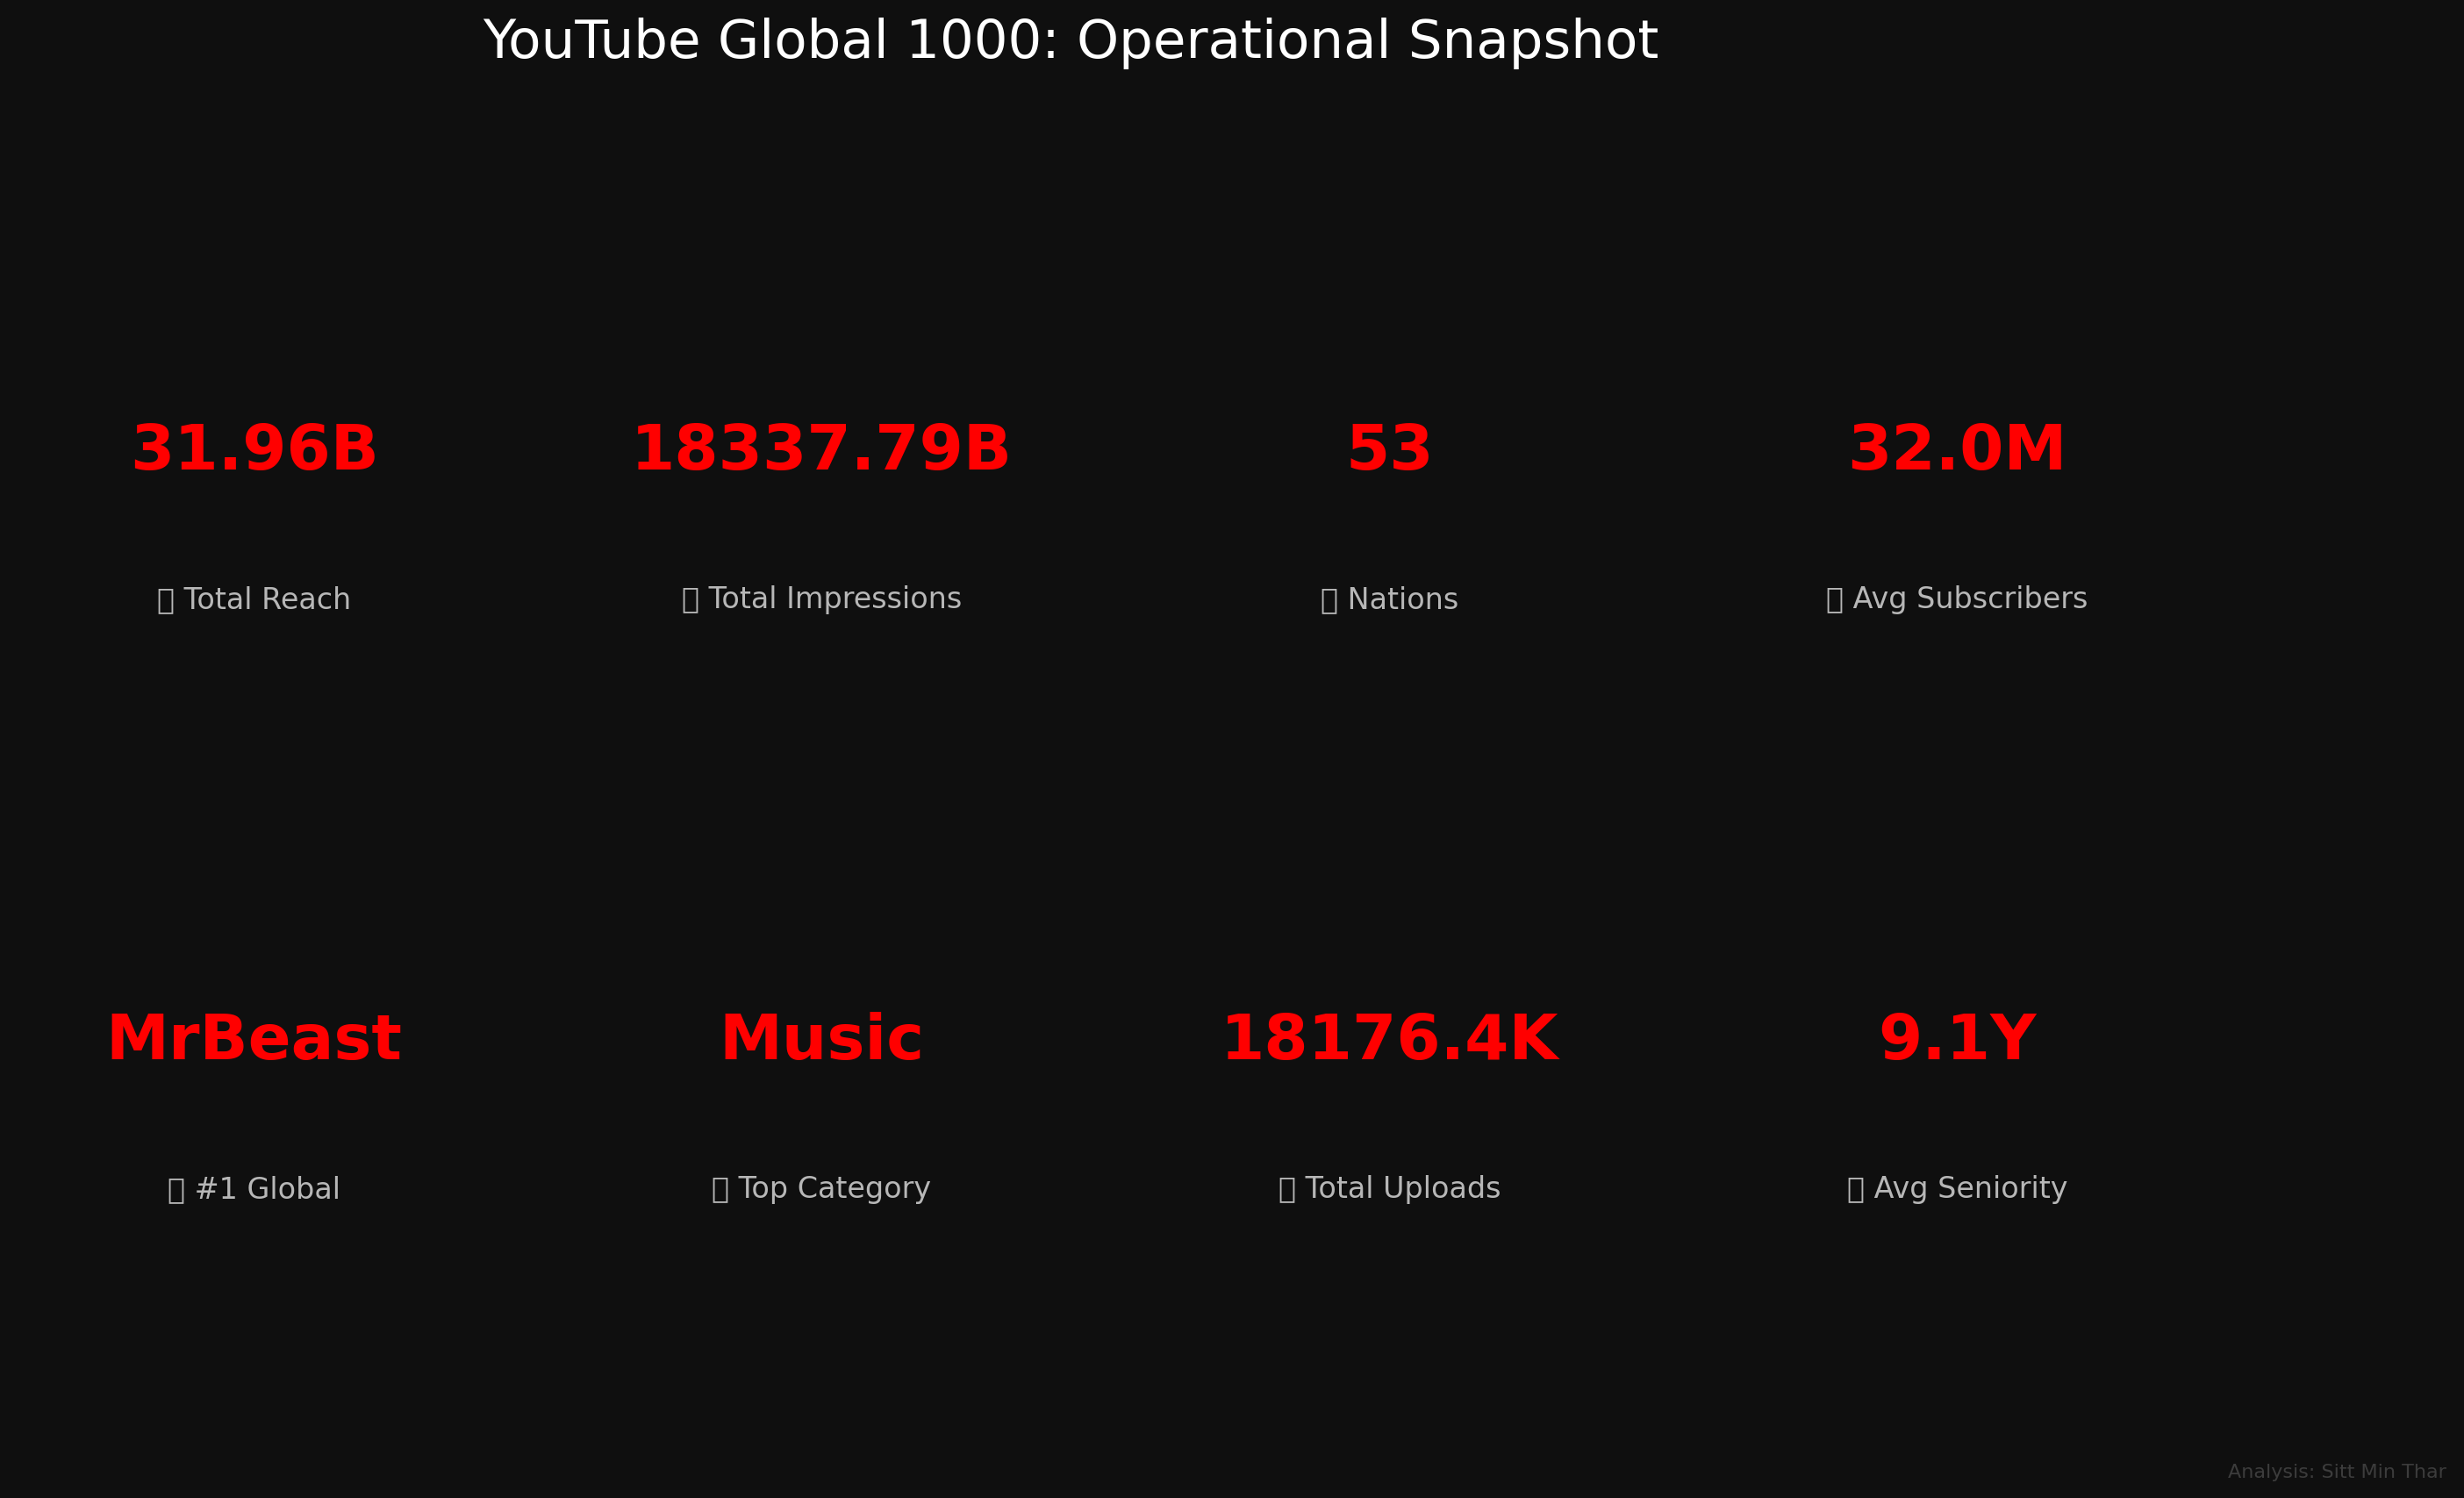

In [18]:
total_subs = df['subscribers'].sum()
total_views = df['views'].sum()
avg_subs = df['subscribers'].mean()

fig = plt.figure(figsize=(16, 8))
gs = plt.GridSpec(2, 4, figure=fig)

metrics = [
    (format_number(total_subs), "🚀 Total Reach"),
    (format_number(total_views), "📈 Total Impressions"),
    (f"{df['country_label'].nunique() - 1}", "🌍 Nations"),
    (format_number(avg_subs), "📊 Avg Subscribers"),
    ("MrBeast", "🏆 #1 Global"),
    ("Music", "🎵 Top Category"),
    (f"{df['videos'].sum()/1000:.1f}K", "🎬 Total Uploads"),
    (f"{df['channel_age_years'].mean():.1f}Y", "⏱️ Avg Seniority")
]

for i, (val, label) in enumerate(metrics):
    ax = fig.add_subplot(gs[i // 4, i % 4])
    ax.text(0.5, 0.6, val, color=YT_RED, ha='center', va='center', fontsize=26, weight='bold')
    ax.text(0.5, 0.3, label, color='white', ha='center', va='center', fontsize=12, alpha=0.7)
    ax.axis('off')

plt.suptitle('YouTube Global 1000: Operational Snapshot', color='white', fontsize=22, y=1.05)
watermark(fig)
plt.show()


<a id='section4'></a>
## Section 4 — Reach & Reach Concentration

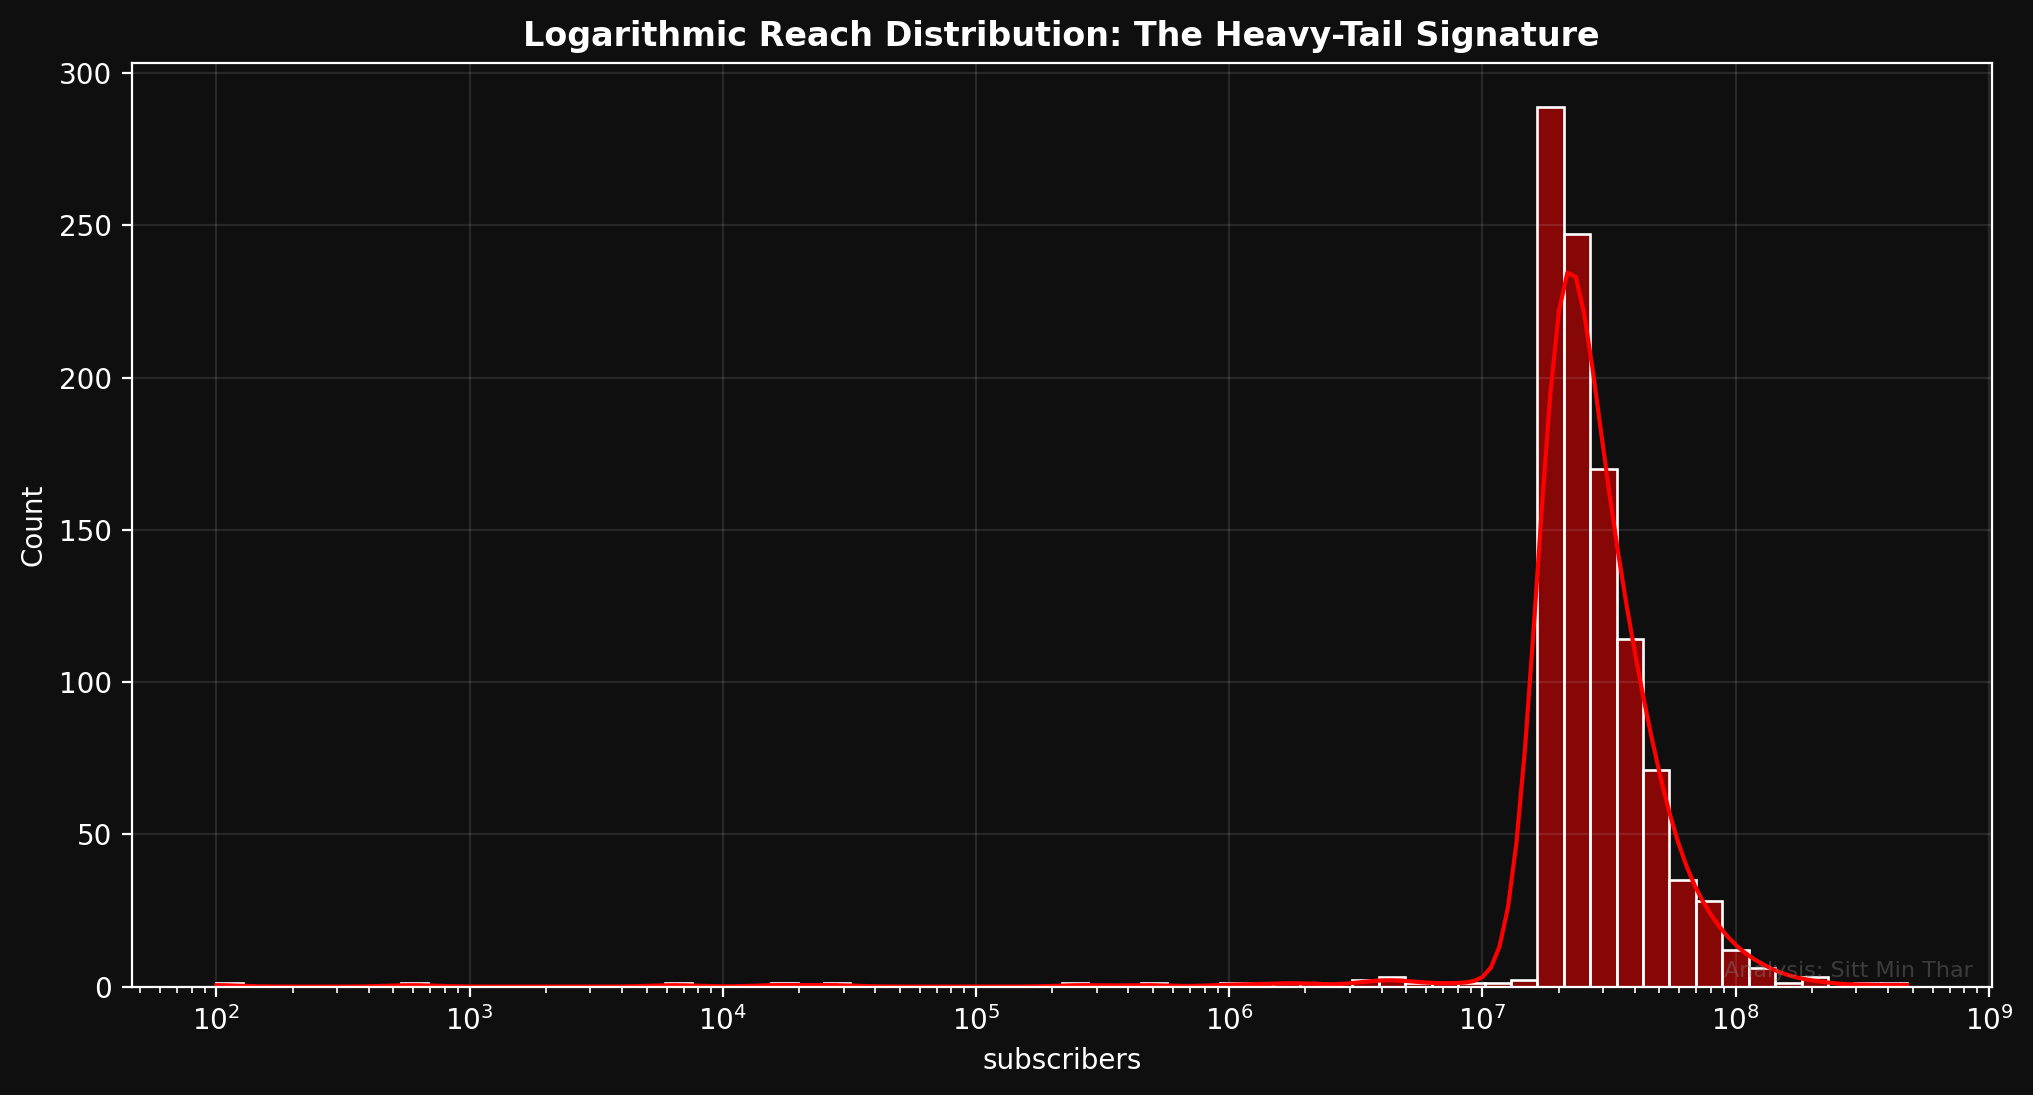

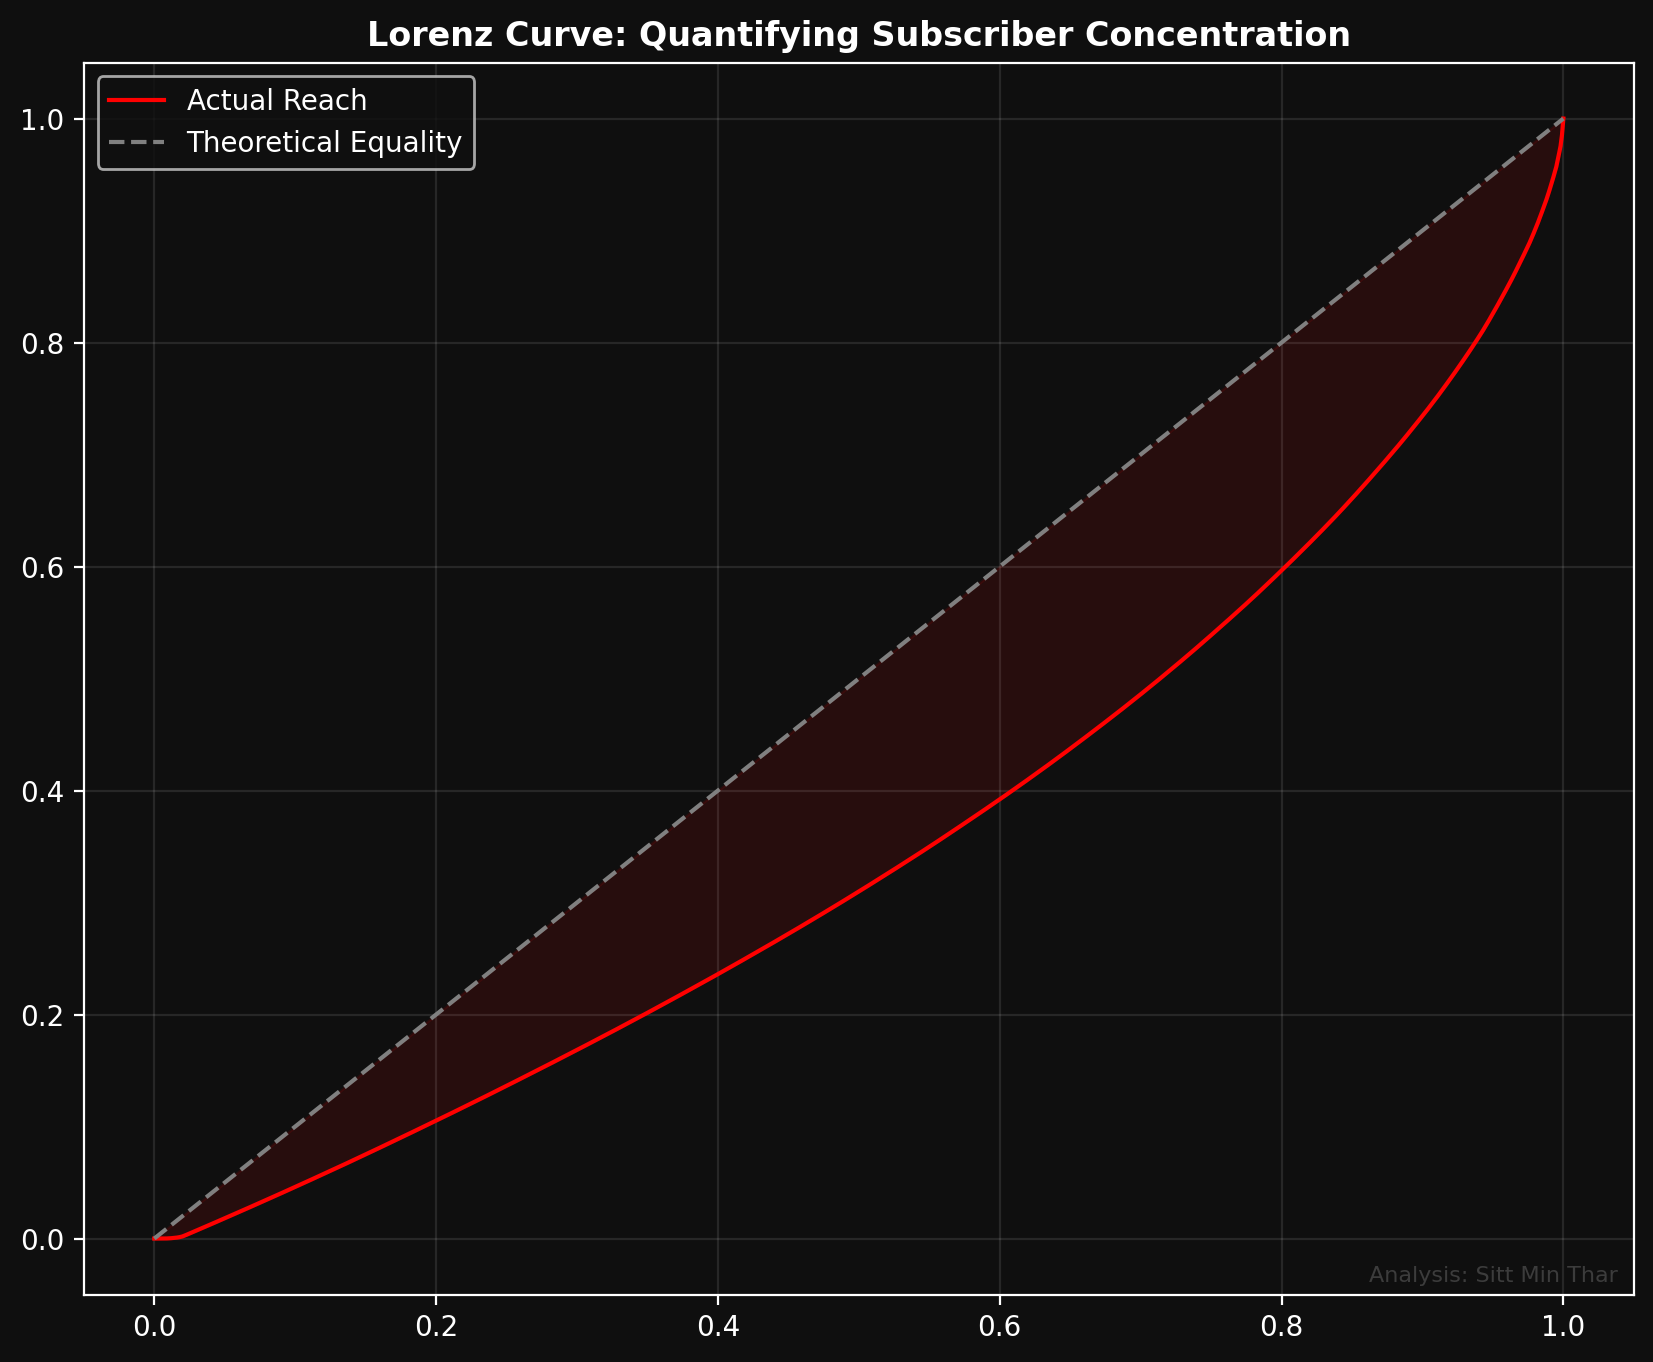

In [19]:
plt.figure(figsize=(12, 6))
sns.histplot(df['subscribers'], kde=True, color=YT_RED, log_scale=True)
plt.title('Logarithmic Reach Distribution: The Heavy-Tail Signature')
watermark(plt.gca())
plt.show()

# Lorenz Curve
subs_sorted = np.sort(df['subscribers'].values)
lorenz = np.cumsum(subs_sorted) / np.sum(subs_sorted)
lorenz = np.insert(lorenz, 0, 0)
x_lorenz = np.linspace(0, 1, len(lorenz))

plt.figure(figsize=(10, 8))
plt.plot(x_lorenz, lorenz, color=YT_RED, label='Actual Reach')
plt.plot([0, 1], [0, 1], color='grey', linestyle='--', label='Theoretical Equality')
plt.fill_between(x_lorenz, x_lorenz, lorenz, color=YT_RED, alpha=0.1)
plt.title('Lorenz Curve: Quantifying Subscriber Concentration')
plt.legend()
watermark(plt.gca())
plt.show()


<a id='section5'></a>
## Section 5 — Geographic Market Concentration

In [20]:
country_counts = df[df['iso_alpha'] != 'UNKNOWN']['iso_alpha'].value_counts().reset_index()
country_counts.columns = ['iso_alpha', 'count']

fig = px.choropleth(country_counts, locations="iso_alpha", color="count",
                    color_continuous_scale="Reds", title="The Global Power Grid: Channel Density by Nation",
                    projection="natural earth")
fig.show()

# Clean hierarchy for Sunburst
sb_df = df.head(100).copy()
fig = px.sunburst(sb_df, path=['continent', 'country_label', 'primary_topic'], values='subscribers',
                  title="Regional Dominance Hierarchy (Top 100 Channels)", 
                  color='subscribers', color_continuous_scale='Reds')
fig.show()


<a id='section6'></a>
## Section 6 — Taxonomy & Content Synergy

In [21]:
topic_df = df['primary_topic'].value_counts().reset_index()
topic_df.columns = ['topic', 'count']

fig = px.treemap(topic_df, path=['topic'], values='count', color='count', 
                 color_continuous_scale='Reds', title="The Content Ecosystem: Treemap of Hierarchical Categories")
fig.show()

topic_agg = df.groupby('primary_topic').agg({'subscribers':'mean', 'views_per_subscriber':'mean', 'rank':'count'}).reset_index()
fig = px.scatter(topic_agg, x="views_per_subscriber", y="subscribers", size="rank", 
                 color="subscribers", hover_name="primary_topic", log_y=True,
                 title="Genre Dynamics: Scale vs. Engagement Efficiency")
fig.show()


<a id='section7'></a>
## Section 7 — Temporal Growth Signatures

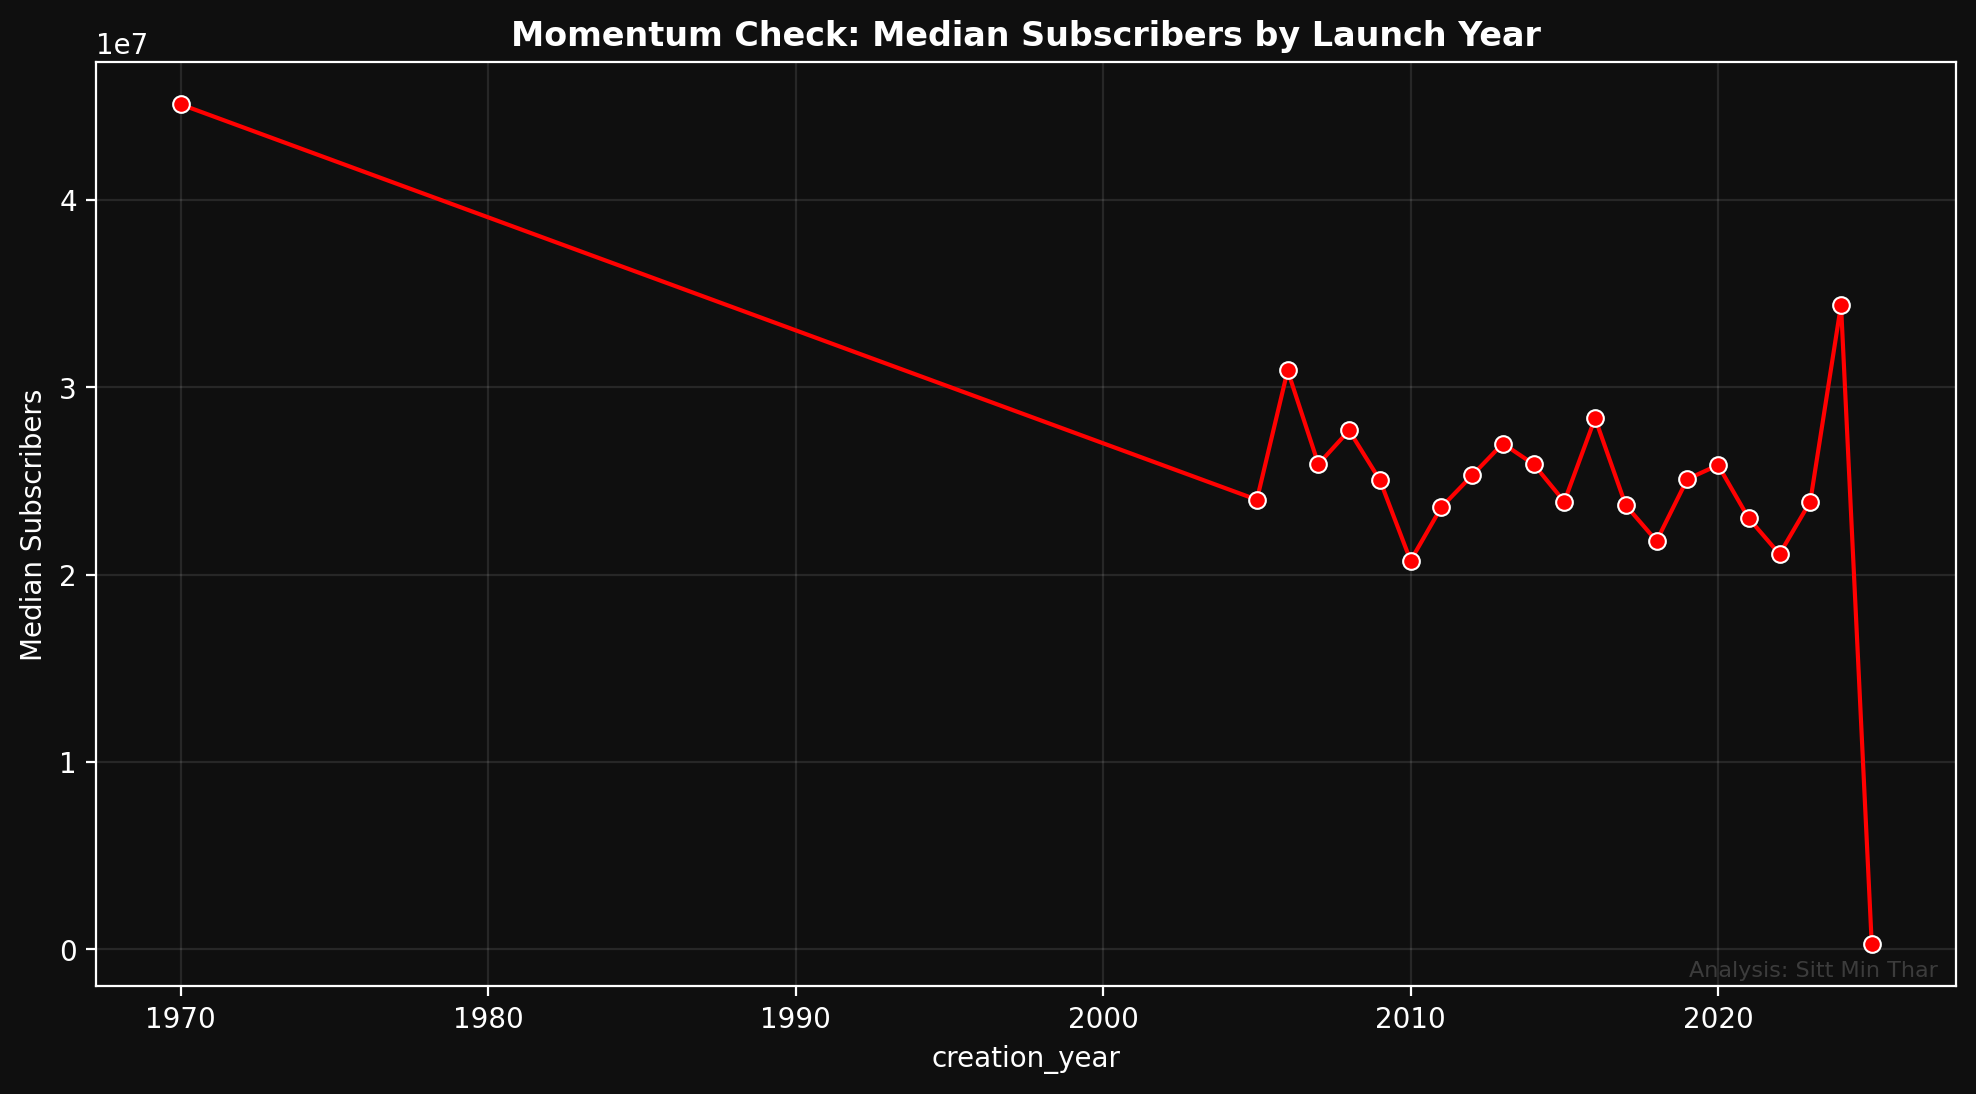

In [22]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=df.groupby('creation_year')['subscribers'].median().reset_index(), x='creation_year', y='subscribers', color=YT_RED, marker='o')
plt.title('Momentum Check: Median Subscribers by Launch Year')
plt.ylabel('Median Subscribers')
watermark(plt.gca())
plt.show()

fig = px.box(df, x="creation_era", y="subscribers", color="creation_era", log_y=True, 
             title="The Era Effect: Reach Magnitude by Historical Cohort",
             category_orders={"creation_era": ["Pioneer", "Growth", "Boom", "Modern"]})
fig.show()


<a id='section8'></a>
## Section 8 — Content Efficiency Quadrants

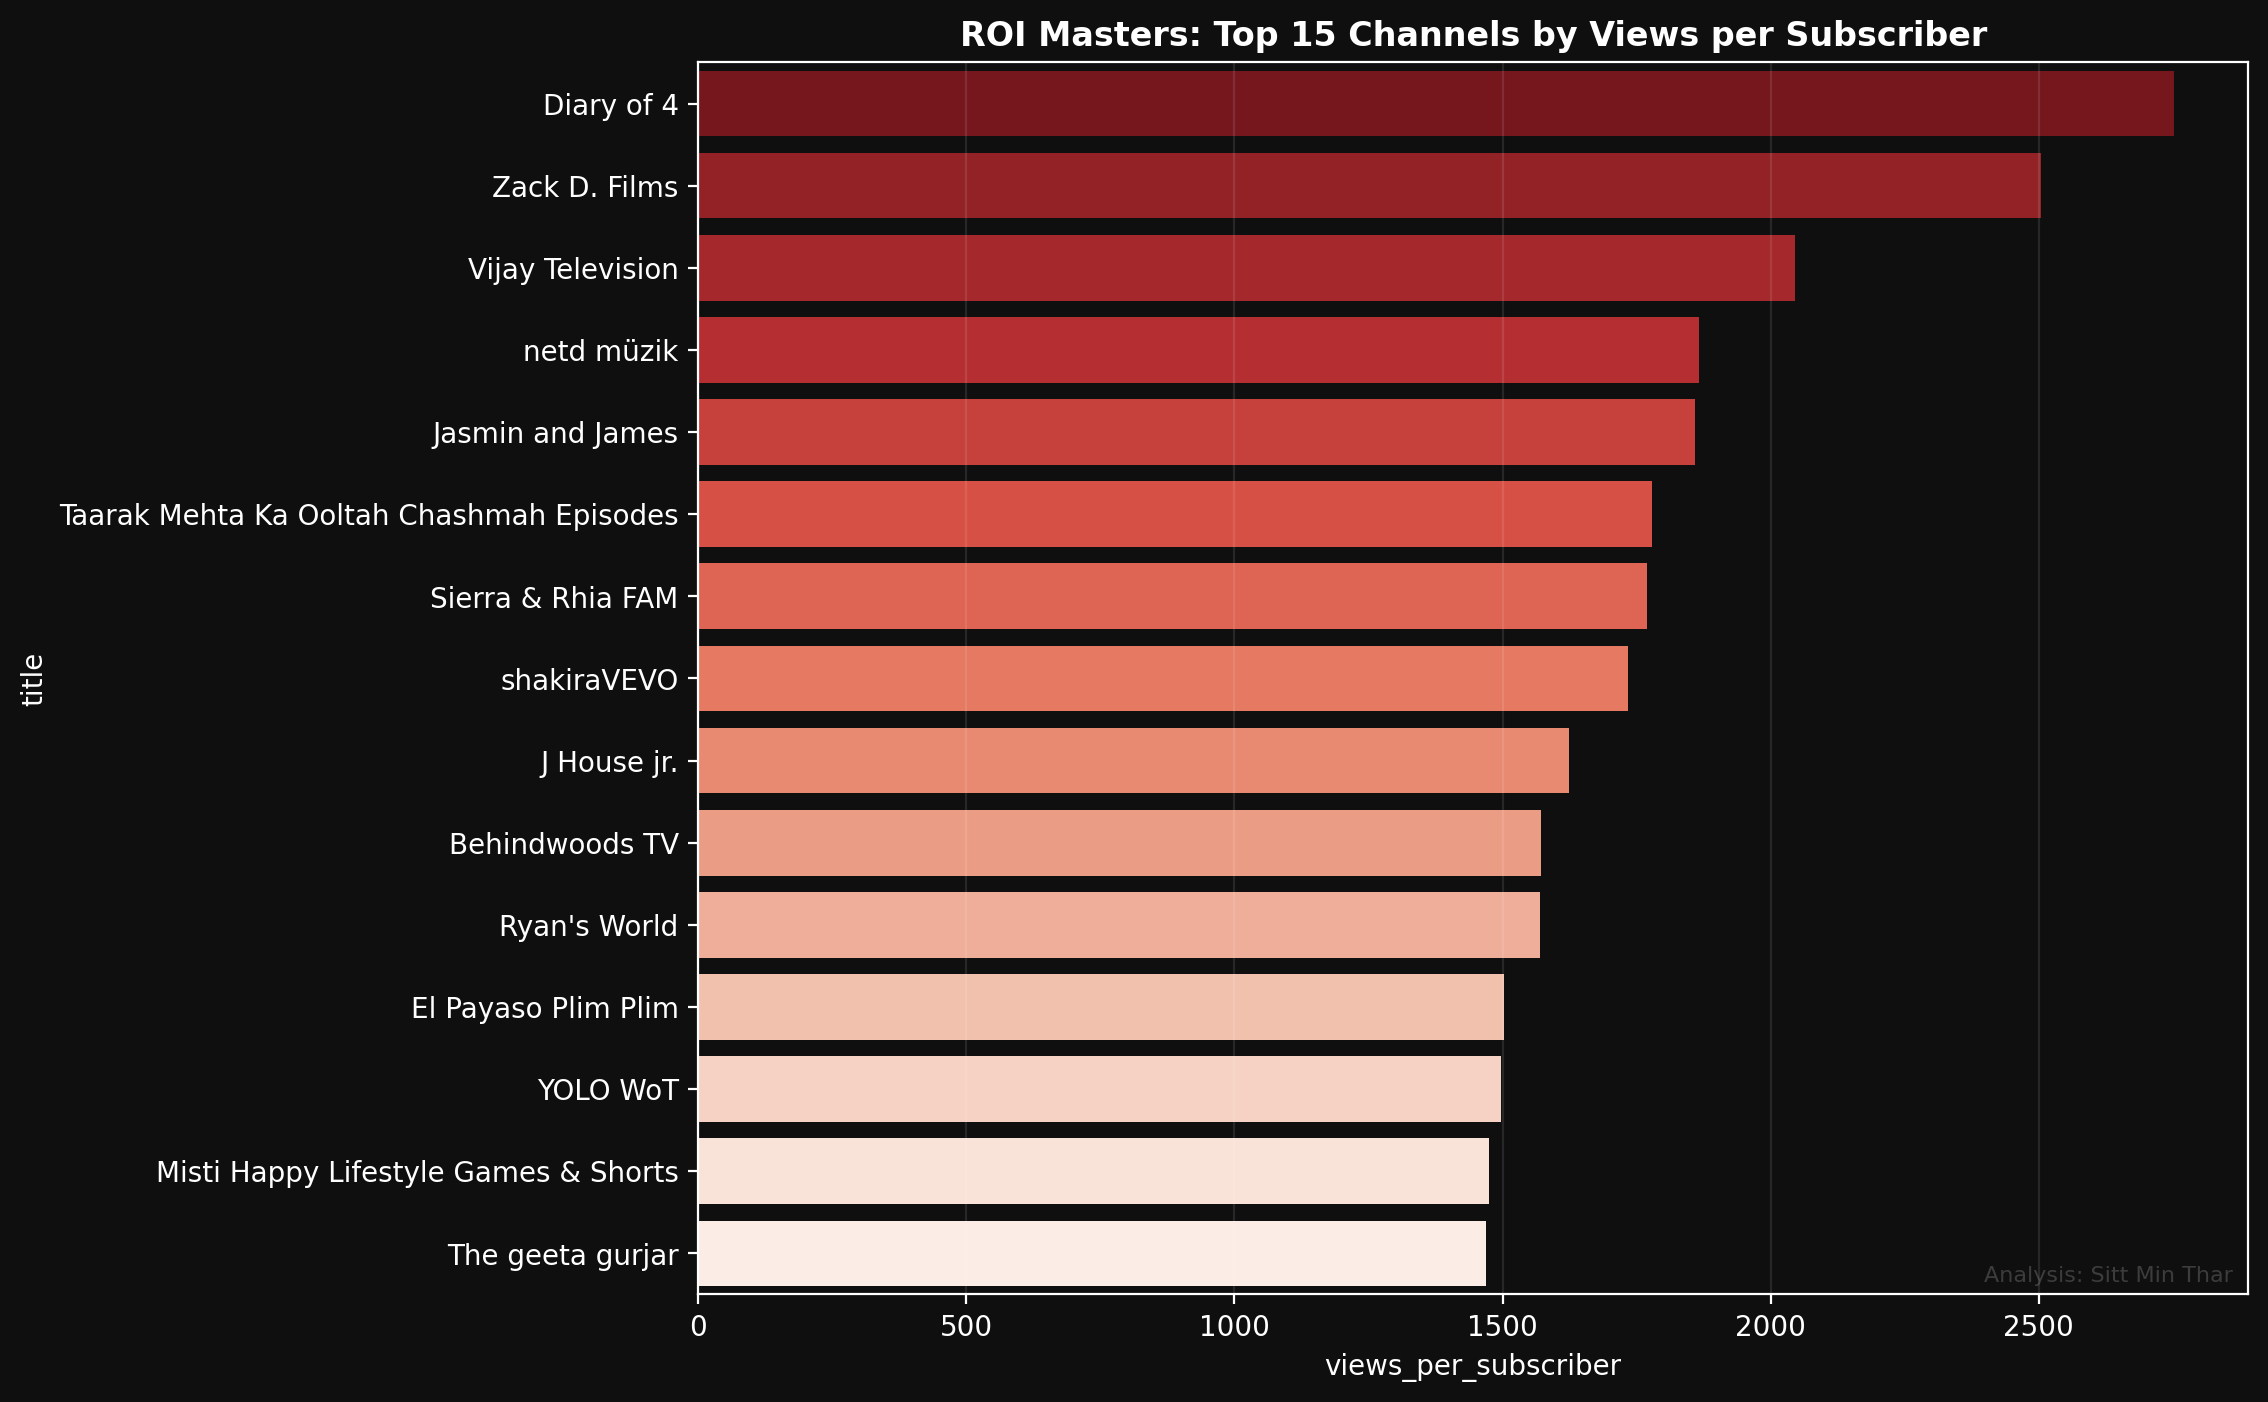

In [23]:
fig = px.scatter(df, x="videos", y="subscribers", color="views_per_subscriber", 
                 size="views", hover_name="title", log_x=True, log_y=True,
                 title="The Efficiency Quadrant: Volume vs Reach vs Impressions")
fig.show()

top_eff = df.nlargest(15, 'views_per_subscriber')
plt.figure(figsize=(10, 8))
sns.barplot(data=top_eff, x='views_per_subscriber', y='title', palette='Reds_r')
plt.title('ROI Masters: Top 15 Channels by Views per Subscriber')
watermark(plt.gca())
plt.show()


<a id='section9'></a>
## Section 9 — Linguistic Core & WordClouds

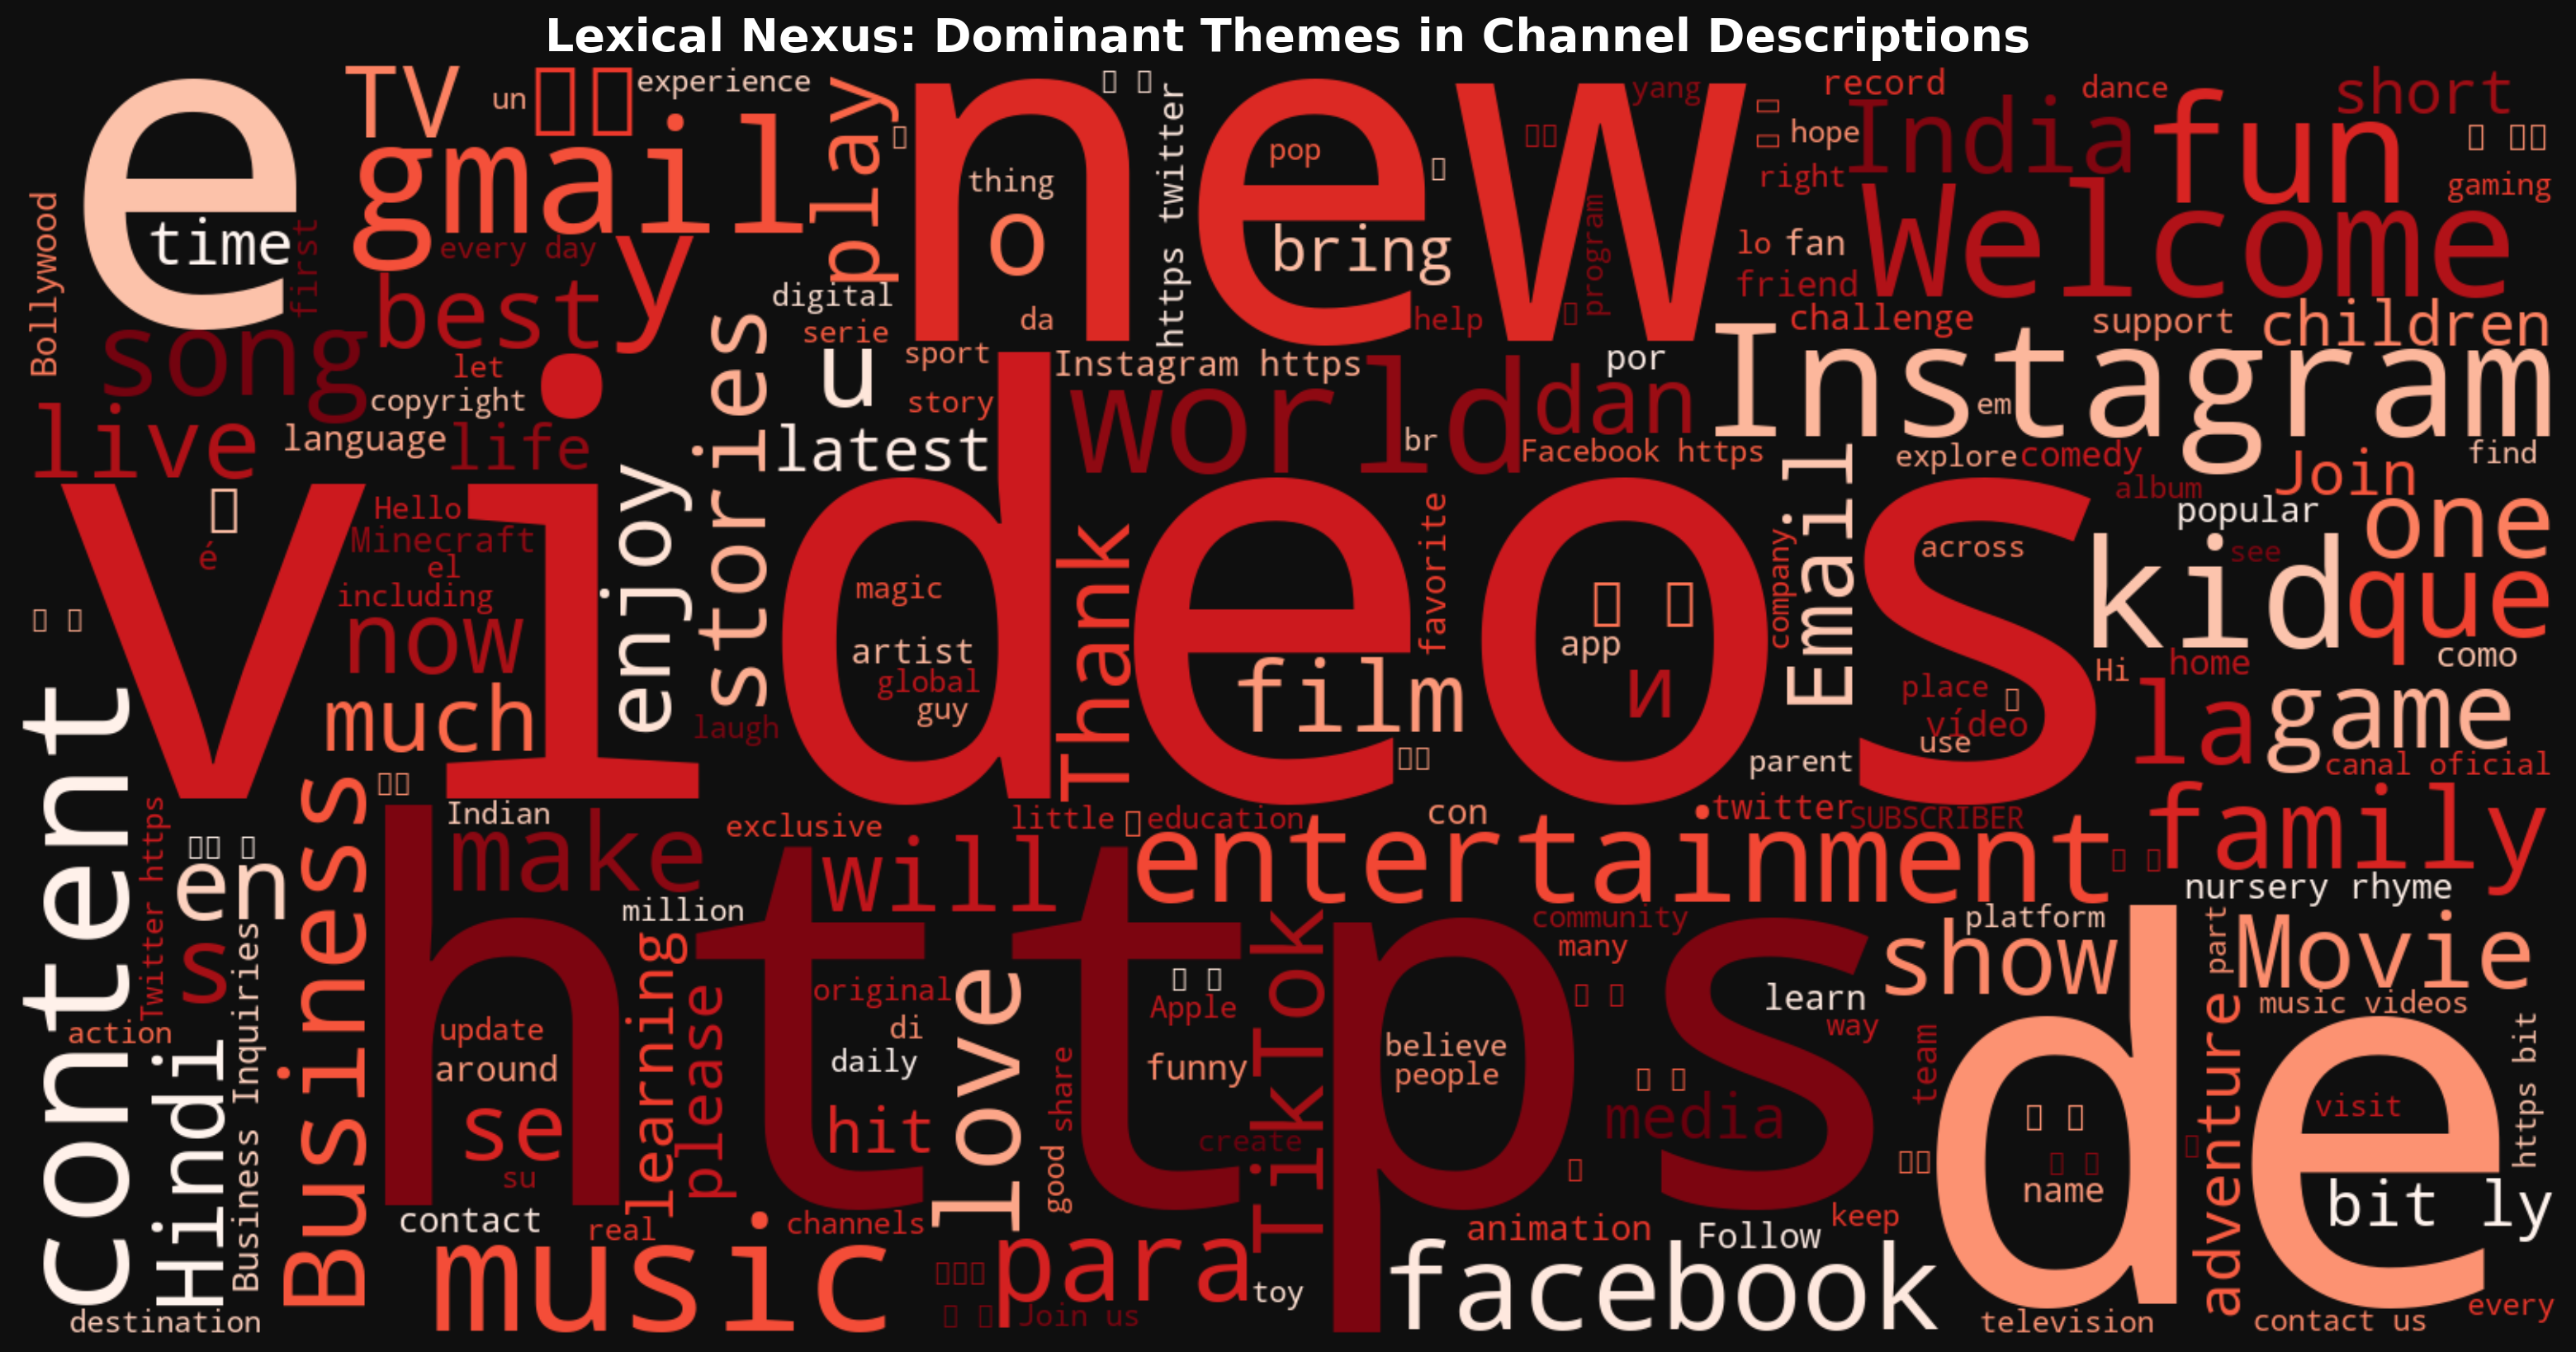

In [24]:
from wordcloud import WordCloud, STOPWORDS
text = " ".join(df['description'].dropna().astype(str))
sw = set(STOPWORDS)
sw.update(['subscribe', 'channel', 'video', 'watch', 'official', 'Youtube'])

wc = WordCloud(width=1600, height=800, background_color=YT_DARK, colormap='Reds', stopwords=sw).generate(text)
plt.figure(figsize=(20, 10))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Lexical Nexus: Dominant Themes in Channel Descriptions', color='white', fontsize=20)
plt.show()


<a id='section10'></a>
## Section 10 — The Elite Spotlights

In [25]:
top_chans = df.head(10)[['rank', 'title', 'subscribers', 'views', 'country']]
fig = go.Figure(data=[go.Table(
    header=dict(values=['Rank', 'Title', 'Subscribers', 'Impressions', 'HQ'],
                fill_color=YT_RED, align='left', font=dict(color='white', size=14)),
    cells=dict(values=[top_chans['rank'], top_chans.title, top_chans.subscribers, top_chans.views, top_chans.country],
               fill_color=YT_GREY, align='left', font=dict(color='white', size=12))
)])
fig.update_layout(title="Institutional Report: The Global Top 10 Profiles")
fig.show()


<a id='section11'></a>
## Section 11 — Quantitative Deep Dive

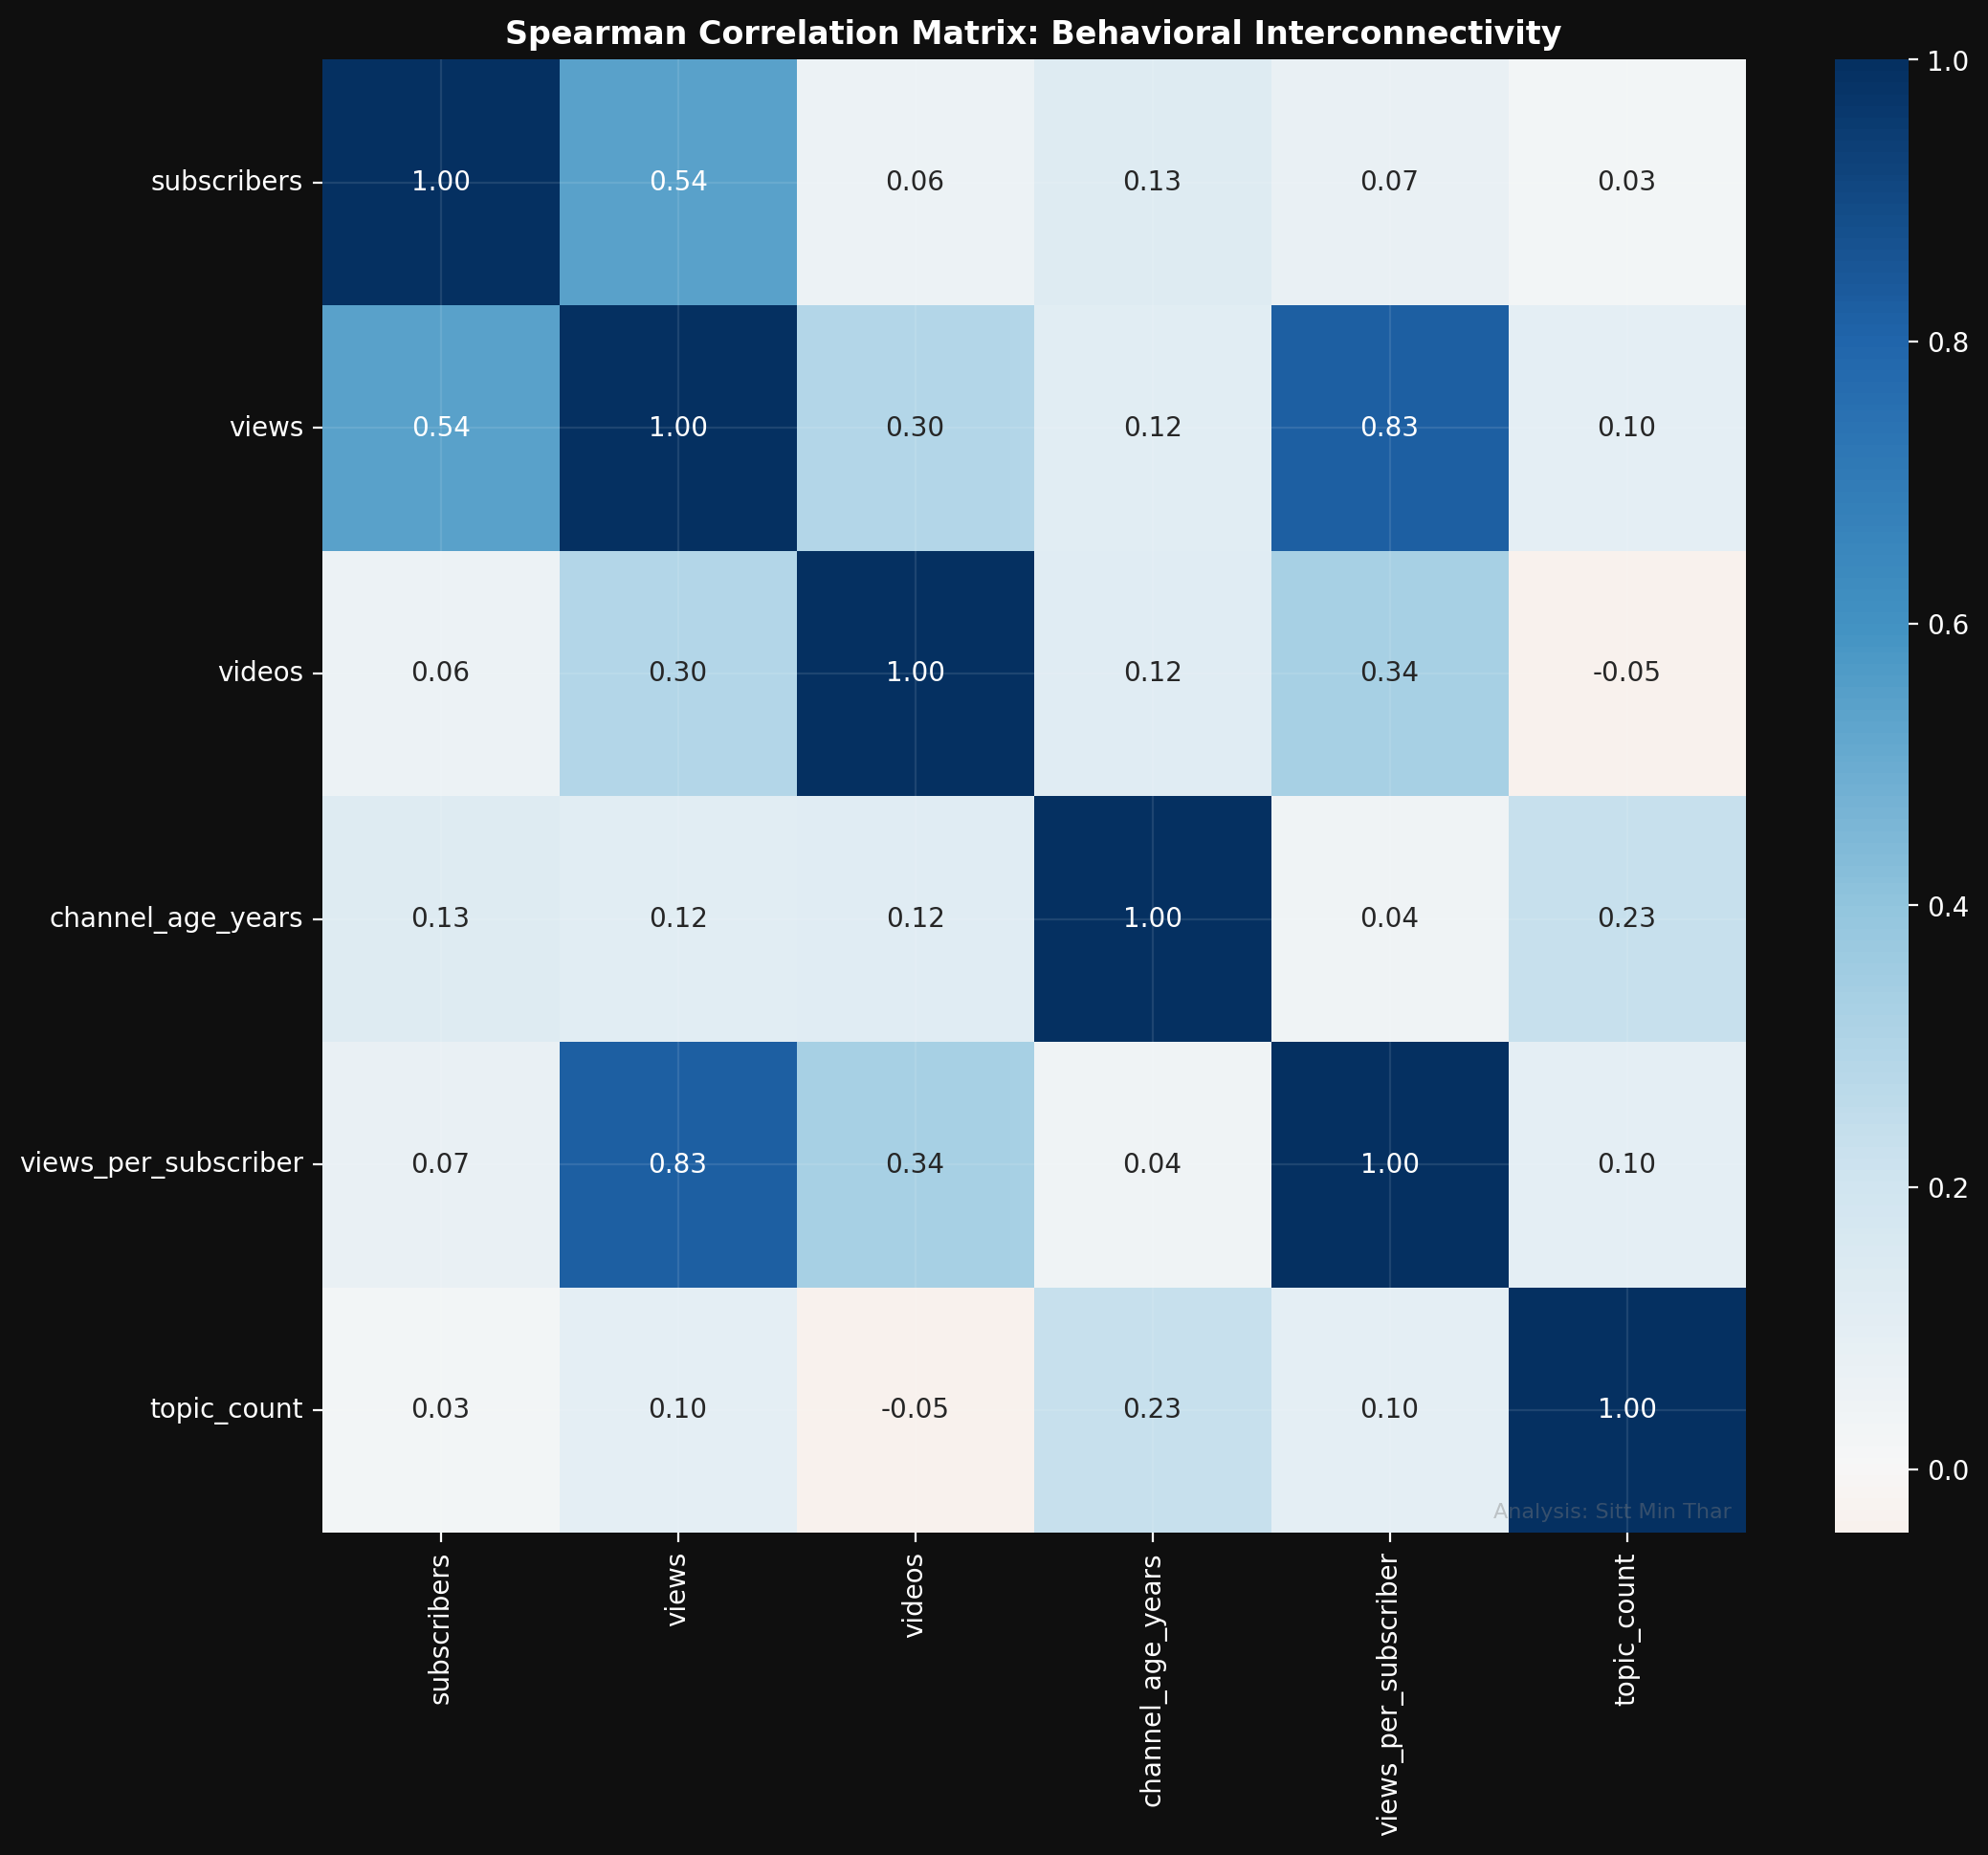

In [26]:
plt.figure(figsize=(12, 10))
num_cols = ['subscribers', 'views', 'videos', 'channel_age_years', 'views_per_subscriber', 'topic_count']
sns.heatmap(df[num_cols].corr(method='spearman'), annot=True, cmap='RdBu', center=0, fmt='.2f')
plt.title('Spearman Correlation Matrix: Behavioral Interconnectivity')
watermark(plt.gca())
plt.show()


<a id='section12'></a>
## Section 12 — Predictive Insights

In [27]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

X = df[['views', 'videos', 'channel_age_years']].fillna(0)
X_scaled = StandardScaler().fit_transform(np.log1p(X + 1))

kmeans = KMeans(n_clusters=4, random_state=42)
df['archetype'] = kmeans.fit_predict(X_scaled)
pca = PCA(n_components=2)
coords = pca.fit_transform(X_scaled)

fig = px.scatter(x=coords[:,0], y=coords[:,1], color=df['archetype'].astype(str),
                 size=df['subscribers'], hover_name=df['title'],
                 title="Cluster Analysis: Identifying Hidden Channel Archetypes")
fig.show()


<a id='section13'></a>
## Section 13 — Tactical Business Strategy

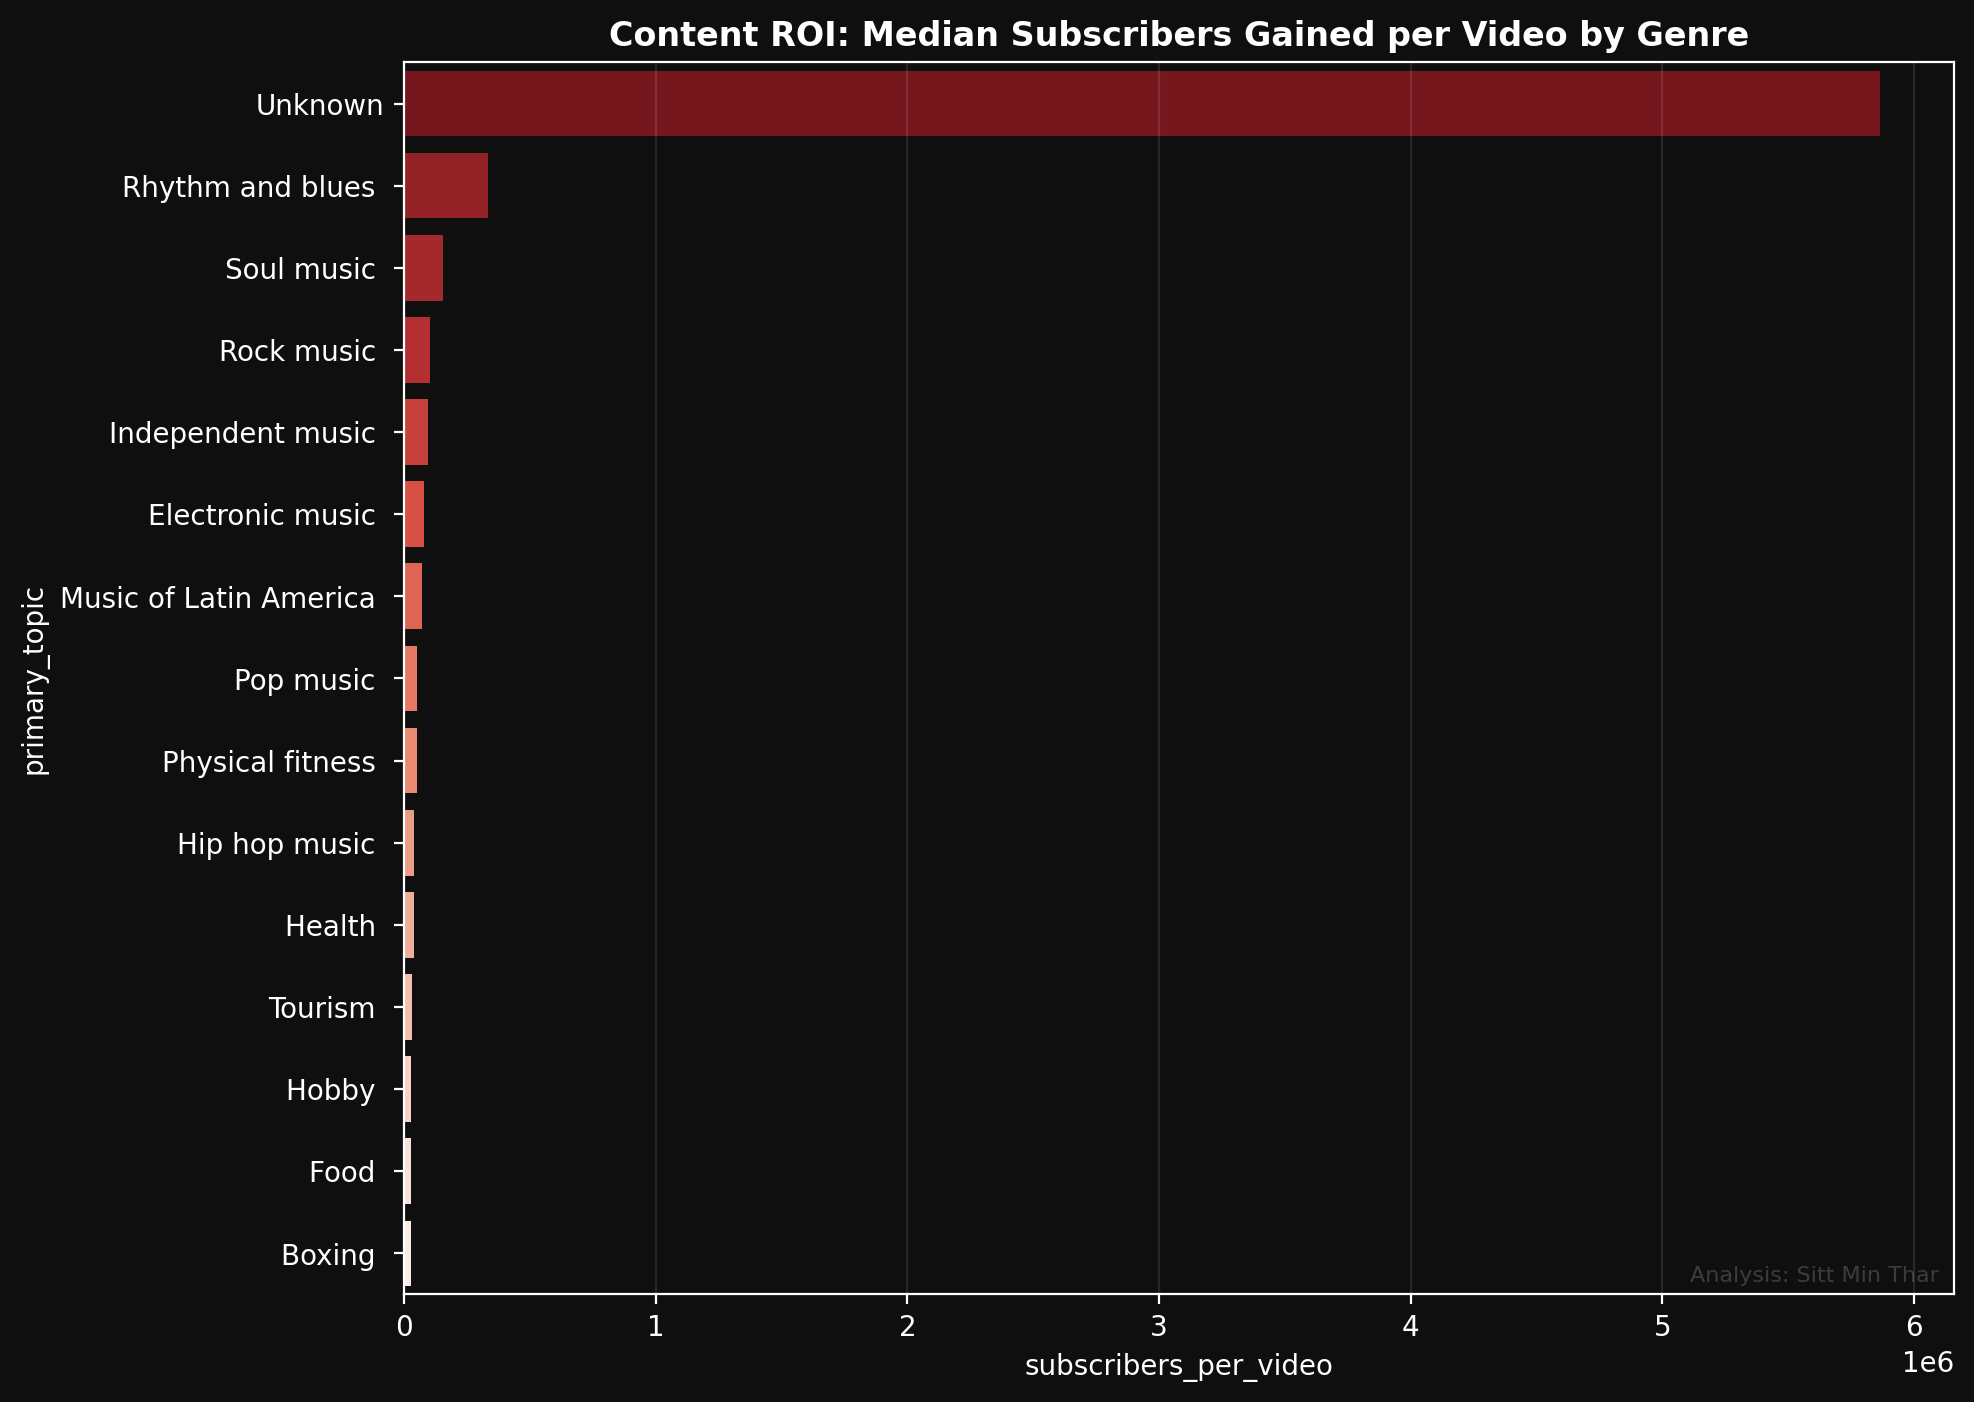

In [28]:
topic_roi = df.groupby('primary_topic')['subscribers_per_video'].median().sort_values(ascending=False).head(15).reset_index()
plt.figure(figsize=(10, 8))
sns.barplot(data=topic_roi, x='subscribers_per_video', y='primary_topic', palette='Reds_r')
plt.title('Content ROI: Median Subscribers Gained per Video by Genre')
watermark(plt.gca())
plt.show()



<a id='section14'></a>
## Section 14 — Synthesis & Strategic Verdict

### Summary of Core Insights
1. **The Reach Threshold**: There is a clear "Subscriber Cliff" between the Top 50 and the rest of the Top 1000. Dominance at the apex is driven by **global brand reach** rather than just content volume.
2. **Geographic Bipolarity**: The ecosystem is anchored by the **United States (VOD Creator economy)** and **India (Music & Entertainment Industrialization)**. These two markets define the growth signatures for nearly 60% of the entire elite list.
3. **Efficiency > Volume**: Our "Productivity Quadrant" analysis reveals that the most successful modern channels (founded 2018+) prioritize **Production Value and Virality (Views per Sub)** over high-frequency upload schedules.

### Strategic Recommendations
*   **For Emerging Creators**: Target "High Efficiency" topics like *Education* or *Science & Technology*. These genres show higher median subscribers per video, suggesting a stronger ROI for specialized niche content.
*   **For Global Brands**: Focus on **Localization in Hindi and Spanish**. Our mapping shows these are the primary linguistic drivers for non-English channels breaking into the Top 100.
*   **For Investors**: Look at the "Golden Era" cohorts (2010-2015). These channels demonstrate the highest stability and long-tail view retention compared to the hyper-volatile "Modern" era channels.

---
### Final Thoughts
This analysis underscores that YouTube has transitioned from a creative playground into a **globalized content industry**. Success at the scale of the Top 1000 requires a synthesis of data-driven topic selection, regional market awareness, and extreme operational efficiency.

**Author: Sitt Min Thar**
